# 03. 지도학습 (Supervised Learning)
### 선형회귀 / 로지스틱회귀 / 랜덤포레스트 / XGBoost
---

## 0. 라이브러리 불러오기

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import warnings
warnings.filterwarnings('ignore')

from scipy.sparse import load_npz

# 지도학습 모델
from sklearn.linear_model    import LinearRegression, LogisticRegression
from sklearn.ensemble        import RandomForestClassifier
from xgboost                 import XGBClassifier

# 평가지표
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix,
    mean_absolute_error, mean_squared_error, r2_score
)

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

print('라이브러리 로딩 완료 ✅')

라이브러리 로딩 완료 ✅


---
## 1. 전처리 결과 불러오기

In [22]:
# TF-IDF 행렬
X_train = load_npz('../data/preprocessed/X_train_tfidf.npz')
X_test  = load_npz('../data/preprocessed/X_test_tfidf.npz')

# 분류용 label (0/1) - index_col=0 : 원본 행 번호 복원
y_clf_train = pd.read_csv('../data/preprocessed/y_clf_train.csv', index_col=0).squeeze()
y_clf_test  = pd.read_csv('../data/preprocessed/y_clf_test.csv',  index_col=0).squeeze()

# 회귀용 label (1,2,4,5) - index_col=0 : 원본 행 번호 복원
y_reg_train = pd.read_csv('../data/preprocessed/y_reg_train.csv', index_col=0).squeeze()
y_reg_test  = pd.read_csv('../data/preprocessed/y_reg_test.csv',  index_col=0).squeeze()

print('데이터 로딩 완료 ✅')
print(f'학습 X shape : {X_train.shape}')
print(f'테스트 X shape : {X_test.shape}')

데이터 로딩 완료 ✅
학습 X shape : (159336, 10000)
테스트 X shape : (39835, 10000)


---
## 2. 선형회귀 (Linear Regression)
> 목표 : 리뷰 텍스트로 **별점 수치** 예측 (회귀 문제)
>
> 평가지표 : MAE (평균 절대 오차), RMSE, R²

In [23]:
print('=== 선형회귀 학습 중... ===')
lr = LinearRegression()
lr.fit(X_train, y_reg_train)
print('학습 완료 ✅')

=== 선형회귀 학습 중... ===
학습 완료 ✅


In [24]:
y_reg_pred = lr.predict(X_test)

mae  = mean_absolute_error(y_reg_test, y_reg_pred)
rmse = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred))
r2   = r2_score(y_reg_test, y_reg_pred)

print('=== 선형회귀 평가 결과 ===')
print(f'MAE  (평균 절대 오차) : {mae:.4f}  ← 예측이 평균 {mae:.2f}점 차이남')
print(f'RMSE (루트 평균 제곱) : {rmse:.4f}')
print(f'R²   (설명력)         : {r2:.4f}  ← 1에 가까울수록 좋음')
print()
print('예측값 범위 :', round(y_reg_pred.min(), 2), '~', round(y_reg_pred.max(), 2))
print('실제값 범위 :', y_reg_test.min(), '~', y_reg_test.max())

=== 선형회귀 평가 결과 ===
MAE  (평균 절대 오차) : 0.8159  ← 예측이 평균 0.82점 차이남
RMSE (루트 평균 제곱) : 1.0577
R²   (설명력)         : 0.5866  ← 1에 가까울수록 좋음

예측값 범위 : -0.46 ~ 6.76
실제값 범위 : 1 ~ 5


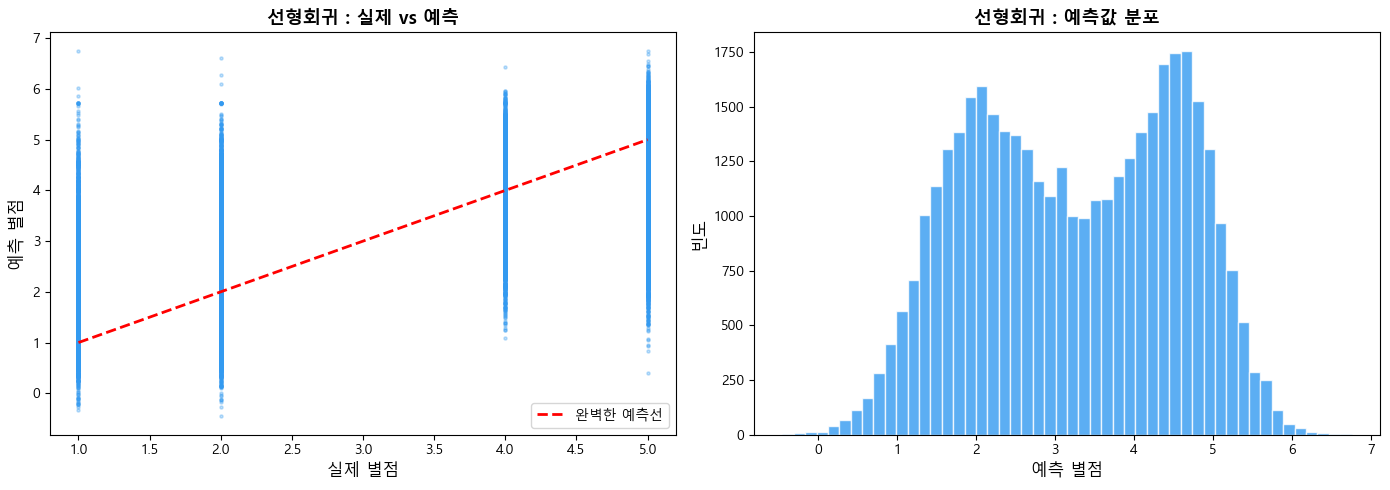

저장 완료 ✅


In [25]:
# 실제 vs 예측 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 산점도
axes[0].scatter(y_reg_test, y_reg_pred, alpha=0.3, color='#339AF0', s=5)
axes[0].plot([1, 5], [1, 5], 'r--', linewidth=2, label='완벽한 예측선')
axes[0].set_title('선형회귀 : 실제 vs 예측', fontsize=13, fontweight='bold')
axes[0].set_xlabel('실제 별점', fontsize=12)
axes[0].set_ylabel('예측 별점', fontsize=12)
axes[0].legend(fontsize=10)

# 예측값 분포
axes[1].hist(y_reg_pred, bins=50, color='#339AF0', edgecolor='white', alpha=0.8)
axes[1].set_title('선형회귀 : 예측값 분포', fontsize=13, fontweight='bold')
axes[1].set_xlabel('예측 별점', fontsize=12)
axes[1].set_ylabel('빈도', fontsize=12)

plt.tight_layout()
plt.savefig('../output/07_linear_regression.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장 완료 ✅')

---

## 📝 선형회귀 분석 결과 및 한계점

### 평가 결과 요약

| 지표 | 수치 | 해석 |
|---|---|---|
| MAE | 0.8159 | 예측값이 실제 별점과 평균 **0.82점** 차이남 |
| RMSE | 1.0577 | MAE보다 크다 → 크게 틀린 케이스 존재 |
| R² | 0.5866 | 데이터 변동의 **59%만** 설명 가능 |
| 예측 범위 | -0.46 ~ 6.76 | 실제 범위(1~5)를 **벗어난 값** 발생 |

---

### 선형회귀가 적합하지 않은 이유

- **이산형 데이터** : 별점은 1, 2, 4, 5 처럼 딱 떨어지는 값인데 선형회귀는 연속된 직선으로 예측하려 함
- **범위 초과** : 예측값이 -0.46 ~ 6.76으로 실제 존재하지 않는 값 출력
- **중간값 쏠림** : 애매한 리뷰를 전부 3점 근처로 예측하는 현상 발생
- **설명력 부족** : R² = 0.59로 데이터의 41%를 설명하지 못함

### 결론
> 이 데이터는 수치 예측보다 **긍정(4\~5점) / 부정(1\~2점)** 으로 나누는 **분류 문제** 로 접근하는 것이 적절함

---
## 3. 로지스틱회귀 (Logistic Regression)
> 목표 : 리뷰 텍스트로 **긍정/부정** 분류
>
> 평가지표 : Accuracy, F1-score, Precision, Recall

In [26]:
print('=== 로지스틱회귀 학습 중... ===')
logit = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
logit.fit(X_train, y_clf_train)
print('학습 완료 ✅')

=== 로지스틱회귀 학습 중... ===
학습 완료 ✅


In [27]:
y_logit_pred = logit.predict(X_test)

print('=== 로지스틱회귀 평가 결과 ===')
print(f'Accuracy  : {accuracy_score(y_clf_test, y_logit_pred):.4f}')
print(f'F1-score  : {f1_score(y_clf_test, y_logit_pred):.4f}')
print(f'Precision : {precision_score(y_clf_test, y_logit_pred):.4f}')
print(f'Recall    : {recall_score(y_clf_test, y_logit_pred):.4f}')
print()
print(classification_report(y_clf_test, y_logit_pred, target_names=['부정(0)', '긍정(1)']))

=== 로지스틱회귀 평가 결과 ===
Accuracy  : 0.8900
F1-score  : 0.8898
Precision : 0.8922
Recall    : 0.8873

              precision    recall  f1-score   support

       부정(0)       0.89      0.89      0.89     19909
       긍정(1)       0.89      0.89      0.89     19926

    accuracy                           0.89     39835
   macro avg       0.89      0.89      0.89     39835
weighted avg       0.89      0.89      0.89     39835



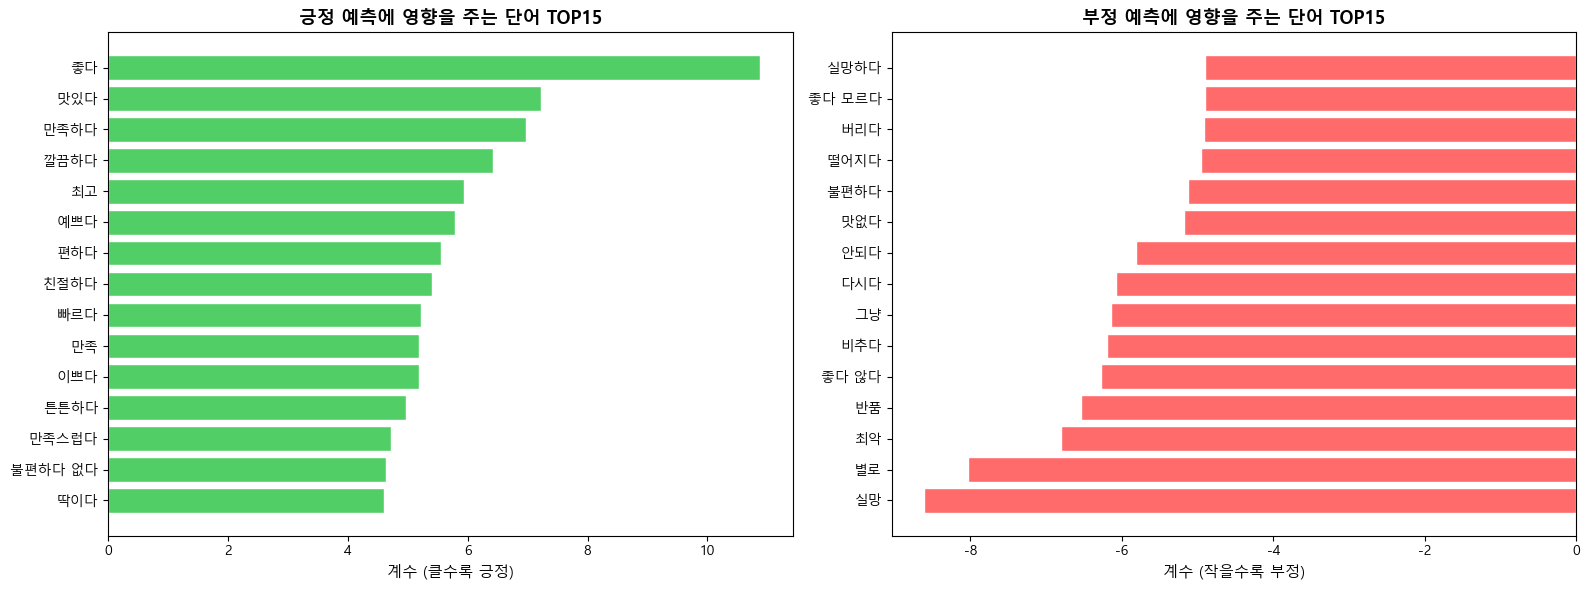

저장 완료 ✅


In [28]:
# 로지스틱회귀 : 중요 단어 확인 (계수 기반)
with open('../data/preprocessed/tfidf_vectorizer.pkl', 'rb') as f:
    tfidf = pickle.load(f)

feature_names = tfidf.get_feature_names_out()
coef          = logit.coef_[0]

top_pos_idx = coef.argsort()[::-1][:15]   # 긍정에 영향
top_neg_idx = coef.argsort()[:15]          # 부정에 영향

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 긍정 영향 단어
axes[0].barh([feature_names[i] for i in top_pos_idx[::-1]],
             [coef[i] for i in top_pos_idx[::-1]], color='#51CF66', edgecolor='white')
axes[0].set_title('긍정 예측에 영향을 주는 단어 TOP15', fontsize=13, fontweight='bold')
axes[0].set_xlabel('계수 (클수록 긍정)', fontsize=11)

# 부정 영향 단어
axes[1].barh([feature_names[i] for i in top_neg_idx],
             [coef[i] for i in top_neg_idx], color='#FF6B6B', edgecolor='white')
axes[1].set_title('부정 예측에 영향을 주는 단어 TOP15', fontsize=13, fontweight='bold')
axes[1].set_xlabel('계수 (작을수록 부정)', fontsize=11)

plt.tight_layout()
plt.savefig('../output/08_logistic_coef.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장 완료 ✅')

---
## 4. 랜덤포레스트 (Random Forest)
> 목표 : 리뷰 텍스트로 **긍정/부정** 분류
>
> 의사결정나무 여러 개를 합쳐서 더 강력하게 만든 모델

In [29]:
print('=== 랜덤포레스트 학습 중... ===')
rf = RandomForestClassifier(
    n_estimators=100,   # 나무 100개
    max_depth=20,
    random_state=42,
    n_jobs=-1           # CPU 최대 활용
)
rf.fit(X_train, y_clf_train)
print('학습 완료 ✅')

=== 랜덤포레스트 학습 중... ===
학습 완료 ✅


In [30]:
y_rf_pred = rf.predict(X_test)

print('=== 랜덤포레스트 평가 결과 ===')
print(f'Accuracy  : {accuracy_score(y_clf_test, y_rf_pred):.4f}')
print(f'F1-score  : {f1_score(y_clf_test, y_rf_pred):.4f}')
print(f'Precision : {precision_score(y_clf_test, y_rf_pred):.4f}')
print(f'Recall    : {recall_score(y_clf_test, y_rf_pred):.4f}')
print()
print(classification_report(y_clf_test, y_rf_pred, target_names=['부정(0)', '긍정(1)']))

=== 랜덤포레스트 평가 결과 ===
Accuracy  : 0.8422
F1-score  : 0.8383
Precision : 0.8600
Recall    : 0.8176

              precision    recall  f1-score   support

       부정(0)       0.83      0.87      0.85     19909
       긍정(1)       0.86      0.82      0.84     19926

    accuracy                           0.84     39835
   macro avg       0.84      0.84      0.84     39835
weighted avg       0.84      0.84      0.84     39835



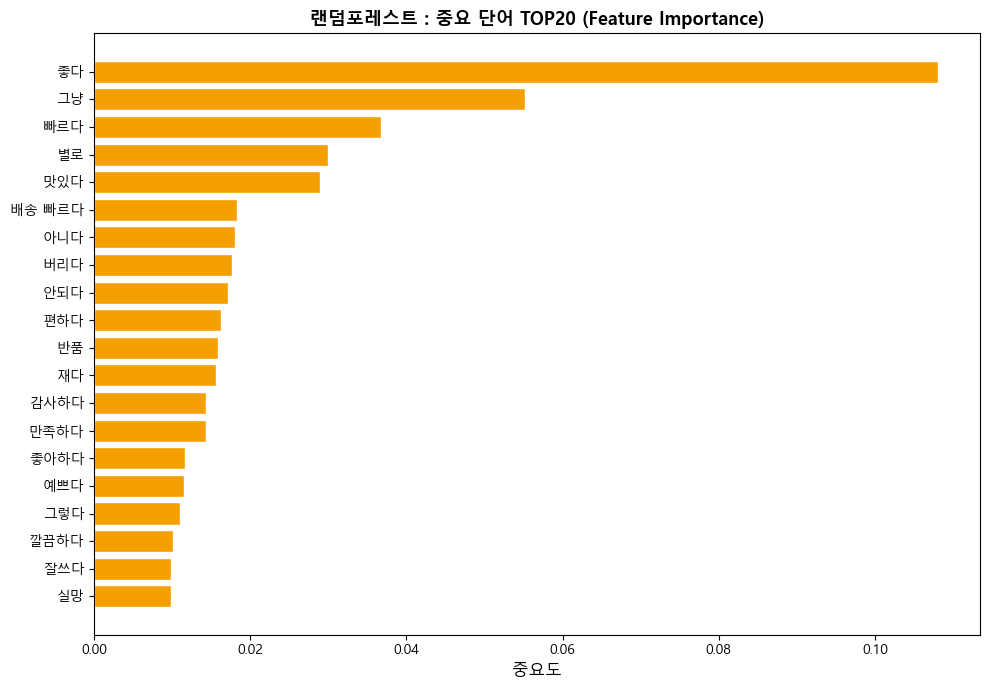

저장 완료 ✅


In [31]:
# 랜덤포레스트 : 중요 단어 (feature importance)
importances   = rf.feature_importances_
top_imp_idx   = importances.argsort()[::-1][:20]
top_imp_words = [feature_names[i] for i in top_imp_idx]
top_imp_vals  = [importances[i] for i in top_imp_idx]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top_imp_words[::-1], top_imp_vals[::-1], color='#F59F00', edgecolor='white')
ax.set_title('랜덤포레스트 : 중요 단어 TOP20 (Feature Importance)', fontsize=13, fontweight='bold')
ax.set_xlabel('중요도', fontsize=12)
plt.tight_layout()
plt.savefig('../output/09_rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장 완료 ✅')

---
## 5. XGBoost
> 목표 : 리뷰 텍스트로 **긍정/부정** 분류

In [32]:
print('=== XGBoost 학습 중... ===')
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss',
    n_jobs=-1
)
xgb.fit(X_train, y_clf_train)
print('학습 완료 ✅')

=== XGBoost 학습 중... ===
학습 완료 ✅


In [33]:
y_xgb_pred = xgb.predict(X_test)

print('=== XGBoost 평가 결과 ===')
print(f'Accuracy  : {accuracy_score(y_clf_test, y_xgb_pred):.4f}')
print(f'F1-score  : {f1_score(y_clf_test, y_xgb_pred):.4f}')
print(f'Precision : {precision_score(y_clf_test, y_xgb_pred):.4f}')
print(f'Recall    : {recall_score(y_clf_test, y_xgb_pred):.4f}')
print()
print(classification_report(y_clf_test, y_xgb_pred, target_names=['부정(0)', '긍정(1)']))

=== XGBoost 평가 결과 ===
Accuracy  : 0.8545
F1-score  : 0.8514
Precision : 0.8704
Recall    : 0.8333

              precision    recall  f1-score   support

       부정(0)       0.84      0.88      0.86     19909
       긍정(1)       0.87      0.83      0.85     19926

    accuracy                           0.85     39835
   macro avg       0.86      0.85      0.85     39835
weighted avg       0.86      0.85      0.85     39835



---
## 6. 모델 성능 비교

In [34]:
results = {
    '로지스틱회귀'  : y_logit_pred,
    '랜덤포레스트'  : y_rf_pred,
    'XGBoost'       : y_xgb_pred,
}

summary = []
for name, pred in results.items():
    summary.append({
        '모델'       : name,
        'Accuracy'   : round(accuracy_score(y_clf_test, pred), 4),
        'F1-score'   : round(f1_score(y_clf_test, pred), 4),
        'Precision'  : round(precision_score(y_clf_test, pred), 4),
        'Recall'     : round(recall_score(y_clf_test, pred), 4),
    })

df_summary = pd.DataFrame(summary)
print('=== 분류 모델 성능 비교 ===')
print(df_summary.to_string(index=False))

=== 분류 모델 성능 비교 ===
     모델  Accuracy  F1-score  Precision  Recall
 로지스틱회귀    0.8900    0.8898     0.8922  0.8873
 랜덤포레스트    0.8422    0.8383     0.8600  0.8176
XGBoost    0.8545    0.8514     0.8704  0.8333


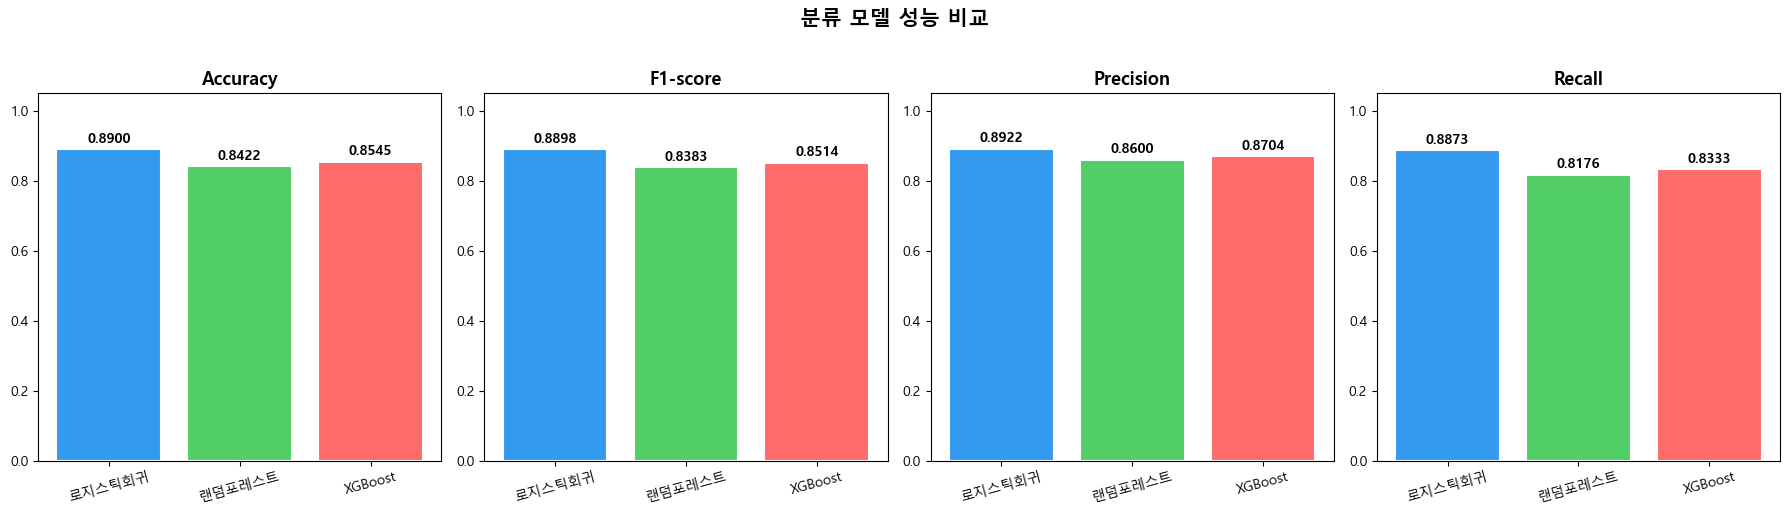

저장 완료 ✅


In [35]:
metrics   = ['Accuracy', 'F1-score', 'Precision', 'Recall']
models    = df_summary['모델'].tolist()
colors    = ['#339AF0', '#51CF66', '#FF6B6B']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, metric in zip(axes, metrics):
    vals = df_summary[metric].tolist()
    bars = ax.bar(models, vals, color=colors, edgecolor='white', linewidth=1.5)
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('분류 모델 성능 비교', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../output/10_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장 완료 ✅')

---
## 7. 혼동 행렬 (Confusion Matrix)

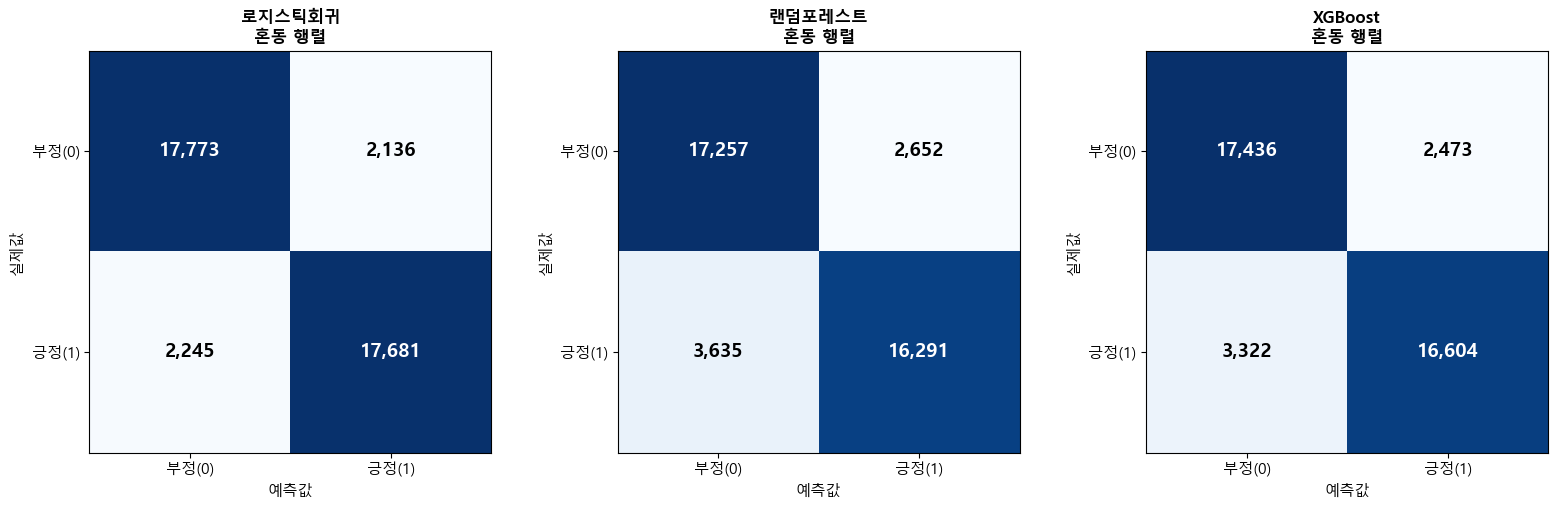

저장 완료 ✅


In [36]:
import itertools

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, pred) in zip(axes, results.items()):
    cm = confusion_matrix(y_clf_test, pred)
    im = ax.imshow(cm, cmap='Blues')
    ax.set_title(f'{name}\n혼동 행렬', fontsize=12, fontweight='bold')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['부정(0)', '긍정(1)'], fontsize=11)
    ax.set_yticklabels(['부정(0)', '긍정(1)'], fontsize=11)
    ax.set_xlabel('예측값', fontsize=11)
    ax.set_ylabel('실제값', fontsize=11)
    for i, j in itertools.product(range(2), range(2)):
        ax.text(j, i, f'{cm[i, j]:,}', ha='center', va='center',
                fontsize=14, fontweight='bold',
                color='white' if cm[i, j] > cm.max()/2 else 'black')

plt.tight_layout()
plt.savefig('../output/11_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장 완료 ✅')

---
## 8. Tableau용 결과 저장

In [37]:
df_clean = pd.read_csv('../data/preprocessed/reviews_clean.csv', encoding='utf-8-sig')

# 테스트 데이터 인덱스 기준으로 원본 내용 복원 (원본 인덱스 유지)
test_idx = y_clf_test.index
df_test  = df_clean.loc[test_idx]  # reset_index 하지 않아 원본 df_clean 인덱스 보존

# 각 모델 예측값 추가 (numpy 배열 → 위치 기반 할당)
df_test = df_test.copy()
df_test['pred_logistic']  = y_logit_pred
df_test['pred_rf']        = y_rf_pred
df_test['pred_xgb']       = y_xgb_pred
df_test['pred_score_lr']  = y_reg_pred  # 선형회귀 별점 예측

# 정답 여부 컬럼 추가 (.values로 인덱스 정렬 없이 위치 기반 비교)
df_test['correct_logistic'] = (df_test['pred_logistic'].values == y_clf_test.values).astype(int)
df_test['correct_rf']       = (df_test['pred_rf'].values       == y_clf_test.values).astype(int)
df_test['correct_xgb']      = (df_test['pred_xgb'].values      == y_clf_test.values).astype(int)

# index=True : 원본 행 번호를 저장 → 04_unsupervised 결과와 인덱스 기반 join 가능
df_test.to_csv('../output/supervised_results.csv', index=True, encoding='utf-8-sig')

print('Tableau용 CSV 저장 완료 ✅')
print(f'저장 경로 : output/supervised_results.csv')
print(f'shape : {df_test.shape}')
df_test.head()

Tableau용 CSV 저장 완료 ✅
저장 경로 : output/supervised_results.csv
shape : (39835, 13)


,score,content,label,content_len,content_clean,content_token,pred_logistic,pred_rf,pred_xgb,pred_score_lr,correct_logistic,correct_rf,correct_xgb
49081,5,"재구매 단맛,짠맛이 적당해서 맛있네요.",1,21,재구매 단맛 짠맛이 적당해서 맛있네요,재다 단맛 짠맛 적당하다 맛있다,1,1,1,3.774998,1,1,1
112278,1,재구매 불량이 엄청나네요 사탕마다 죄다끈적거리고,0,26,재구매 불량이 엄청나네요 사탕마다 죄다끈적거리고,재다 불량 엄청나다 사탕 끈 거리,0,0,0,2.137872,1,1,1
2770,2,작동이 잘안됐어요ㅠ,0,10,작동이 잘안됐어요,작동 돼다,0,0,0,2.534545,1,1,1
45953,5,재구매 그럭저럭 마음에들고 좋아요.,1,19,재구매 그럭저럭 마음에들고 좋아요,재다 마음 들다 좋다,1,1,1,5.109655,1,1,1
161037,2,좋아요 만족,0,6,좋아요 만족,좋다 만족,1,1,1,4.608329,0,0,0


---
## ✅ 지도학습 완료 요약

| 모델 | 종류 | 목표 |
|---|---|---|
| 선형회귀 | 회귀 | 별점 수치 예측 |
| 로지스틱회귀 | 분류 | 긍/부정 분류 |
| 랜덤포레스트 | 분류 | 긍/부정 분류 |
| XGBoost | 분류 | 긍/부정 분류 |

---
➡️ 다음 : **04_unsupervised.ipynb** (비지도학습 : K-Means / PCA / t-SNE)

---

## 📝 형태소 분석 도입 전/후 성능 비교 및 결론

### 성능 비교 요약

| 지표 | | 로지스틱회귀 | 랜덤포레스트 | XGBoost |
|---|---|---|---|---|
| Accuracy  | 기존 | 0.8722 | 0.7784 | 0.7920 |
|           | 신규 | **0.8900** ✅ | **0.8422** ✅ | **0.8545** ✅ |
| F1-score  | 기존 | 0.8671 | 0.7419 | 0.7611 |
|           | 신규 | **0.8898** ✅ | **0.8383** ✅ | **0.8514** ✅ |
| Precision | 기존 | 0.9035 | 0.8888 | 0.8941 |
|           | 신규 | 0.8922 ⬇️ | 0.8600 ⬇️ | 0.8704 ⬇️ |
| Recall    | 기존 | 0.8335 | 0.6367 | 0.6626 |
|           | 신규 | **0.8873** ✅ | **0.8176** ✅ | **0.8333** ✅ |

---

### 핵심 변화

- **Recall 대폭 개선** : 형태소 분석으로 "좋아요 / 좋네요 / 좋습니다" 를 "좋다" 로 통합한 덕분에 긍정 리뷰 탐지 능력이 크게 향상됨
- **Precision 소폭 하락** : Recall ↑ 하면 Precision ↓ 하는 트레이드오프 관계로 긍정 분류 범위가 넓어진 만큼 오분류도 소폭 증가
- **랜덤포레스트 가장 큰 개선** : Recall 0.6367 → 0.8176 (+0.18) 으로 세 모델 중 가장 극적인 변화

---

### 결론

> 형태소 분석(KoNLPy Okt) 도입으로 **모든 모델의 전반적인 성능이 향상**되었으며
> 특히 기존의 핵심 문제였던 **Recall 저하 문제가 대폭 개선**됨
>
> 이는 단순 공백 기준 분리보다 **의미 단위로 어간을 추출**하는 방식이
> 한국어 감성 분석에 훨씬 효과적임을 보여줌
>
> 세 모델 모두 성능이 향상되었으나 **로지스틱회귀 > XGBoost > 랜덤포레스트** 순위는 유지되어
> TF-IDF 기반 텍스트 분류에는 선형 모델이 가장 적합함을 재확인함

---